# Choosing a Sparse Root Solver

gEconpy provides several solvers for nonlinear systems with sparse Jacobians. All of them are used through
one function, `sparse_root`, which accepts a solver instance. This notebook walks through the available
solvers, shows how to configure them, and compares their behavior on problems of increasing difficulty.

The objective function must return a tuple `(residuals, jacobian)`, where the residual is an ndarray
and the Jacobian is a scipy sparse matrix.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp

from gEconpy.plotting import set_matplotlib_style
from gEconpy.solvers.sparse_root import (
    Chord,
    GaussNewtonTrustRegion,
    InexactNewtonKrylov,
    LevenbergMarquardt,
    NewtonArmijo,
    NewtonNonmonotone,
    SparseDogleg,
    sparse_root,
)

set_matplotlib_style()

## Test Problems

We define three test problems. The first is a small system to demonstrate the API. The second and third
are large sparse systems where solver choice actually matters.

In [2]:
def quadratic(x):
    """x^2 - [1, 4] = 0. Solution at [1, 2]."""
    return x**2 - np.array([1.0, 4.0]), sp.diags(2 * x, format="csc")


def broyden_tridiagonal(x):
    """Broyden tridiagonal system. Classic large sparse test problem."""
    n = len(x)
    res = (3.0 - 2.0 * x) * x + 1.0
    res[:-1] -= 2.0 * x[1:]
    res[1:] -= x[:-1]
    jac = sp.diags(
        [-np.ones(n - 1), 3.0 - 4.0 * x, -2 * np.ones(n - 1)],
        [-1, 0, 1],
        format="csc",
    )
    return res, jac


def trigonometric(x):
    """Trigonometric system (More, Garbow, Hillstrom). Many near-solutions."""
    n = len(x)
    sumcos = np.sum(np.cos(x))
    idx = np.arange(1, n + 1, dtype=np.float64)
    res = float(n) - sumcos + idx * (1.0 - np.cos(x)) - np.sin(x)

    diag_vals = (1.0 + idx) * np.sin(x) - np.cos(x)
    off_diag = np.sin(x)
    J_dense = np.tile(off_diag, (n, 1))
    np.fill_diagonal(J_dense, diag_vals)
    jac = sp.csc_matrix(J_dense)
    return res, jac

## Basic Usage

With no solver argument, `sparse_root` defaults to Newton's method with Armijo backtracking. This is
a good general-purpose choice.

In [3]:
result = sparse_root(quadratic, np.array([2.0, 3.0]), progressbar=False)
print(f"Success: {result.success}")
print(f"Solution: {result.x}")
print(f"Iterations: {result.nit}")

Success: True
Solution: [1. 2.]
Iterations: 5


To choose a different solver, pass an instance to the `solver` argument.

In [4]:
result = sparse_root(quadratic, np.array([2.0, 3.0]), solver=LevenbergMarquardt(), progressbar=False)
print(f"Success: {result.success}, iterations: {result.nit}")

Success: True, iterations: 5


## The Solvers

The solvers fall into two families.

**Line-search solvers** compose a direction strategy with a globalization strategy. They are
constructed via factory functions:
- `NewtonArmijo()` — exact Newton direction + Armijo backtracking
- `Chord()` — reuses the Jacobian for several steps, reducing factorization cost
- `InexactNewtonKrylov()` — solves the Newton system approximately via GMRES, good for very large systems
- `NewtonNonmonotone()` — allows the merit function to increase temporarily, helping escape narrow valleys

**Trust-region solvers** manage their own step acceptance:
- `SparseDogleg()` — Powell dogleg within an adaptive trust region
- `GaussNewtonTrustRegion()` — Gauss-Newton with Steihaug-CG subproblem solver
- `LevenbergMarquardt()` — damped Gauss-Newton with adaptive $\lambda$

Let's compare all seven on the Broyden tridiagonal system at $n = 1000$.

In [5]:
solvers = {
    "NewtonArmijo": NewtonArmijo(),
    "Chord": Chord(),
    "InexactNewtonKrylov": InexactNewtonKrylov(),
    "NewtonNonmonotone": NewtonNonmonotone(),
    "SparseDogleg": SparseDogleg(),
    "GaussNewtonTR": GaussNewtonTrustRegion(),
    "LevenbergMarquardt": LevenbergMarquardt(),
}

n = 1000
x0 = -np.ones(n)

rows = []
for name, solver in solvers.items():
    t0 = time.perf_counter()
    result = sparse_root(broyden_tridiagonal, x0.copy(), solver=solver, progressbar=False)
    elapsed = time.perf_counter() - t0
    rows.append(
        {
            "solver": name,
            "success": result.success,
            "iterations": result.nit,
            "f_evals": result.nfev,
            "max |residual|": f"{np.max(np.abs(result.fun)):.2e}",
            "time (ms)": f"{elapsed * 1000:.1f}",
        }
    )

pd.DataFrame(rows).set_index("solver")

,success,iterations,f_evals,max |residual|,time (ms)
solver,,,,,
NewtonArmijo,True,5,6,6.66e-16,7.9
Chord,True,8,9,4.37e-11,2.3
InexactNewtonKrylov,True,8,9,2.11e-13,4.1
NewtonNonmonotone,True,5,6,6.66e-16,1.5
SparseDogleg,True,7,8,7.77e-16,2.6
GaussNewtonTR,True,7,8,1.11e-15,4.1
LevenbergMarquardt,True,5,6,2.51e-13,2.9


## Composing Direction and Globalization Strategies

The line-search solvers are built from two interchangeable pieces:

- A **direction strategy** computes the search direction at each step
- A **globalization strategy** chooses how far to step in that direction

The factory functions pick sensible defaults, but you can mix and match. For example, here we pair a
Krylov direction (iterative linear solve) with a nonmonotone line search:

In [6]:
from gEconpy.solvers.sparse_root.direction import KrylovDirection
from gEconpy.solvers.sparse_root.globalization import NonmonotoneBacktracking
from gEconpy.solvers.sparse_root.line_search import LineSearchSolver

custom_solver = LineSearchSolver(
    direction=KrylovDirection(krylov_method="gmres"),
    globalization=NonmonotoneBacktracking(memory=10),
)

result = sparse_root(broyden_tridiagonal, -np.ones(1000), solver=custom_solver, progressbar=False)
print(f"Success: {result.success}, iterations: {result.nit}")

Success: True, iterations: 8


## Scaling: Krylov vs Direct Solvers

For large systems, the Jacobian factorization in `NewtonArmijo` can become the bottleneck.
`InexactNewtonKrylov` avoids factorization entirely by solving the Newton system iteratively. Let's see
how they scale on the Broyden tridiagonal system as $n$ grows.

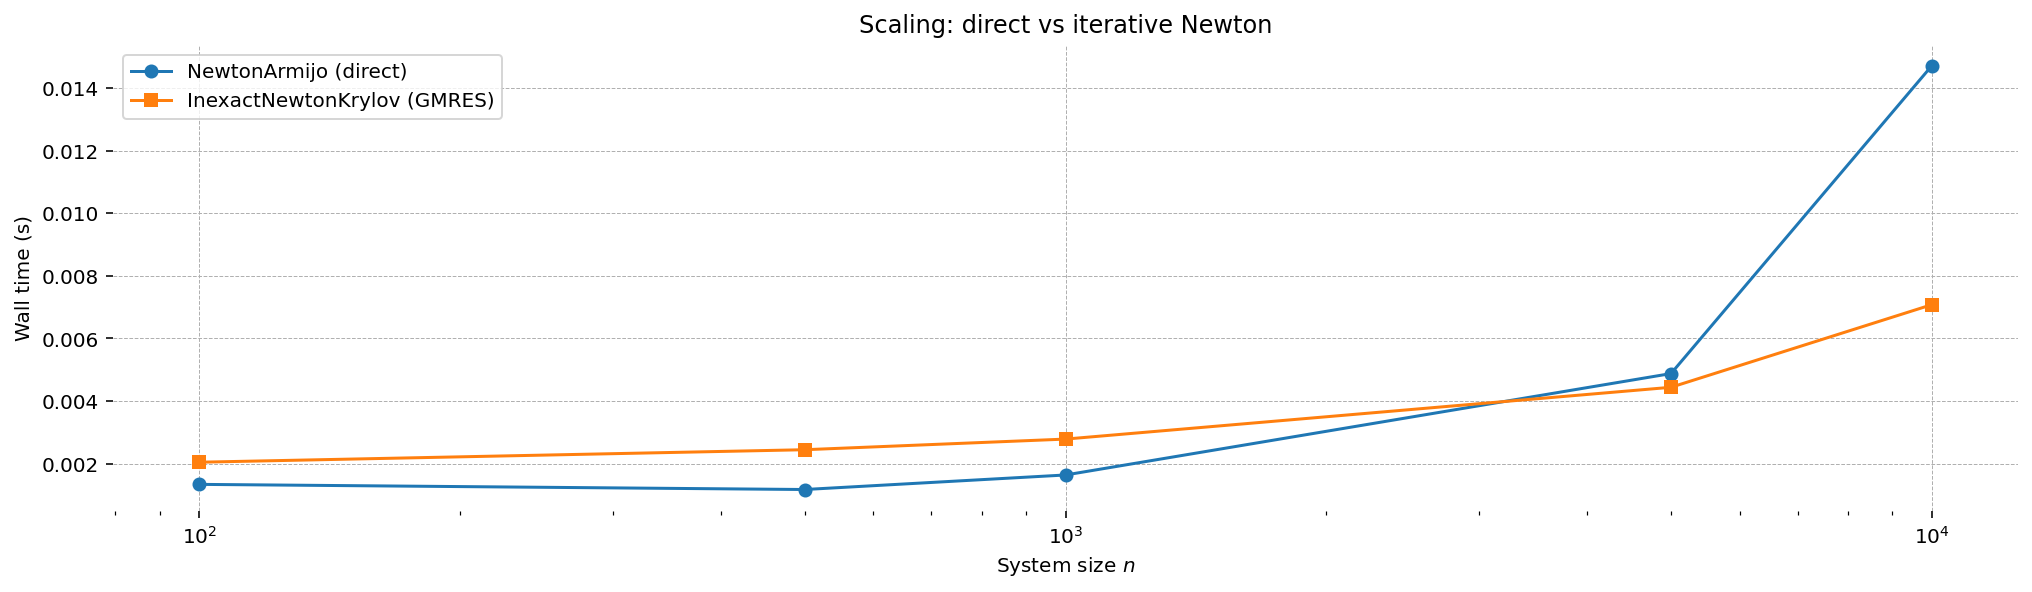

In [7]:
sizes = [100, 500, 1_000, 5_000, 10_000]
newton_times = []
krylov_times = []

for n in sizes:
    x0 = -np.ones(n)

    t0 = time.perf_counter()
    sparse_root(broyden_tridiagonal, x0.copy(), solver=NewtonArmijo(), progressbar=False)
    newton_times.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    sparse_root(broyden_tridiagonal, x0.copy(), solver=InexactNewtonKrylov(), progressbar=False)
    krylov_times.append(time.perf_counter() - t0)

fig, ax = plt.subplots()
ax.plot(sizes, newton_times, "o-", label="NewtonArmijo (direct)")
ax.plot(sizes, krylov_times, "s-", label="InexactNewtonKrylov (GMRES)")
ax.set_xlabel("System size $n$")
ax.set_ylabel("Wall time (s)")
ax.set_title("Scaling: direct vs iterative Newton")
ax.legend()
ax.set_xscale("log")
plt.show()

## Difficult Problems: Trigonometric System

The Moré-Garbow-Hillstrom trigonometric system has many near-solutions and is hard for monotone
line-search methods. Trust-region and nonmonotone solvers tend to do better here.

In [8]:
n = 50
x0 = np.ones(n) / n

rows = []
for name, solver in solvers.items():
    result = sparse_root(trigonometric, x0.copy(), solver=solver, progressbar=False, maxiter=500)
    rows.append(
        {
            "solver": name,
            "success": result.success,
            "iterations": result.nit,
            "f_evals": result.nfev,
            "max |residual|": f"{np.max(np.abs(result.fun)):.2e}",
        }
    )

pd.DataFrame(rows).set_index("solver")

,success,iterations,f_evals,max |residual|
solver,,,,
NewtonArmijo,True,11,38,2.64e-13
Chord,True,28,217,5.00e-11
InexactNewtonKrylov,False,500,7658,1.05e-03
NewtonNonmonotone,True,9,10,4.61e-11
SparseDogleg,True,290,346,4.87e-04
GaussNewtonTR,True,34,70,8.48e-04
LevenbergMarquardt,True,28,50,7.00e-04


## Tuning Solver Parameters

All solvers expose their parameters as constructor arguments. Here are a few examples.

**Armijo parameters**: `c1` controls how much decrease the line search demands. Smaller values are more
permissive (accept steps more readily); larger values are stricter.

In [9]:
from gEconpy.solvers.sparse_root.globalization import ArmijoBacktracking

loose = NewtonArmijo(globalization=ArmijoBacktracking(c1=1e-6))
strict = NewtonArmijo(globalization=ArmijoBacktracking(c1=0.5))

x0_far = np.full(1000, 100.0)

r_loose = sparse_root(broyden_tridiagonal, x0_far.copy(), solver=loose, progressbar=False)
r_strict = sparse_root(broyden_tridiagonal, x0_far.copy(), solver=strict, progressbar=False)

print(f"Loose  c1=1e-6: {r_loose.nit} iterations, {r_loose.nfev} f-evals")
print(f"Strict c1=0.5:  {r_strict.nit} iterations, {r_strict.nfev} f-evals")

Loose  c1=1e-6: 7 iterations, 8 f-evals
Strict c1=0.5:  15 iterations, 31 f-evals


**Chord recompute frequency**: the `Chord` solver reuses the Jacobian factorization for several steps,
trading accuracy for speed. The `recompute_every` parameter controls this tradeoff.

In [10]:
from gEconpy.solvers.sparse_root.direction import ChordDirection

rows = []
for freq in [1, 3, 5, 10, 20]:
    solver = Chord(direction=ChordDirection(recompute_every=freq))
    result = sparse_root(broyden_tridiagonal, -np.ones(1000), solver=solver, progressbar=False)
    rows.append({"recompute_every": freq, "iterations": result.nit, "success": result.success})

pd.DataFrame(rows).set_index("recompute_every")

,iterations,success
recompute_every,,
1,5,True
3,7,True
5,8,True
10,12,True
20,21,True


**Levenberg-Marquardt damping**: the initial damping parameter $\lambda_0$ controls how cautious the
first steps are. Too large and the solver crawls; too small and it may overshoot.

In [11]:
rows = []
for lam0 in [1e-6, 1e-3, 1.0, 100.0]:
    solver = LevenbergMarquardt(lam0=lam0)
    result = sparse_root(broyden_tridiagonal, -np.ones(1000), solver=solver, progressbar=False)
    rows.append({"lam0": lam0, "iterations": result.nit, "f_evals": result.nfev, "success": result.success})

pd.DataFrame(rows).set_index("lam0")

,iterations,f_evals,success
lam0,,,
0.000001,5,6,True
0.001000,5,6,True
1.000000,8,9,True
100.000000,12,13,True


## Cheap Merit Evaluation with `merit_fun`

During backtracking, the line-search solvers evaluate the objective function at every trial step to
check the Armijo condition. By default this calls the full `fun`, which computes both residuals **and**
the Jacobian — even though the Jacobian is only needed at the finally accepted point.

When the Jacobian is expensive (as in large stacked DSGE systems), this is wasteful. You can pass a
`merit_fun` to the globalization strategy that returns **only the residuals**. The solver will use it
for all trial evaluations during backtracking, then call the full `fun` once at the accepted point to
obtain the Jacobian.

In [12]:
def broyden_residuals_only(x):
    """Residuals without the Jacobian — much cheaper to evaluate."""
    len(x)
    res = (3.0 - 2.0 * x) * x + 1.0
    res[:-1] -= 2.0 * x[1:]
    res[1:] -= x[:-1]
    return res


solver_with_merit = NewtonArmijo(globalization=ArmijoBacktracking(merit_fun=broyden_residuals_only))

result = sparse_root(broyden_tridiagonal, -np.ones(1000), solver=solver_with_merit, progressbar=False)
print(f"Success: {result.success}, iterations: {result.nit}, f_evals: {result.nfev}")

Success: True, iterations: 5, f_evals: 11


The solver converges to the same solution but avoids computing the Jacobian at every rejected trial
point. The benefit grows with system size and Jacobian cost — in perfect foresight simulation (below),
the Jacobian involves assembling a block-tridiagonal sparse matrix across hundreds of time periods,
so skipping it during backtracking is a significant win.

## Application: Perfect Foresight Simulation

In practice, these solvers are used under the hood by `ge.solve_perfect_foresight`. A perfect foresight
simulation stacks the model equations across all time periods into one large sparse nonlinear system.
The size of that system grows linearly with the simulation length, so solver choice matters.

`solve_perfect_foresight` automatically compiles a residual-only version of the stacked system and
attaches it as the `merit_fun` on the solver's globalization strategy. You don't need to do anything
— the optimization described in the previous section is applied for you whenever the default
`NewtonArmijo` solver is used, or whenever you pass a line-search solver with an `ArmijoBacktracking`
or `NonmonotoneBacktracking` globalization strategy.

Let's start with the RBC model using defaults, then switch to the larger New Keynesian model with a
custom solver.

### RBC model with defaults

In [13]:
import gEconpy as ge

rbc = ge.model_from_gcn(ge.data.get_example_gcn("RBC"), verbose=False)

T = 500
shock = np.zeros(T)
shock[0] = 0.05

trajectory, result = ge.solve_perfect_foresight(rbc, simulation_length=T, shocks={"epsilon_A": shock})
print(f"Success: {result.success}, iterations: {result.nit}")

Output()

Success: True, iterations: 3


The system solved here has $T \times n_{\text{vars}}$ unknowns. Let's look at how big that is, and
how sparse the Jacobian is at the solution:

In [14]:
n_vars = len(rbc.variables)
print(f"{'Variables per period:':25} {n_vars}")
print(f"{'Simulation length:':25} {T}")
print(f"{'Total unknowns:':25} {T * n_vars:,}")
print(f"{'Jacobian shape':25} {result.jac.shape}")
print(f"{'Jacobian nonzeros:':25} {result.jac.nnz:,}")
print(f"{'Density:':25} {result.jac.nnz / np.prod(result.jac.shape):.6%}")

Variables per period:     9
Simulation length:        500
Total unknowns:           4,500
Jacobian shape            (4500, 4500)
Jacobian nonzeros:        15,492
Density:                  0.076504%


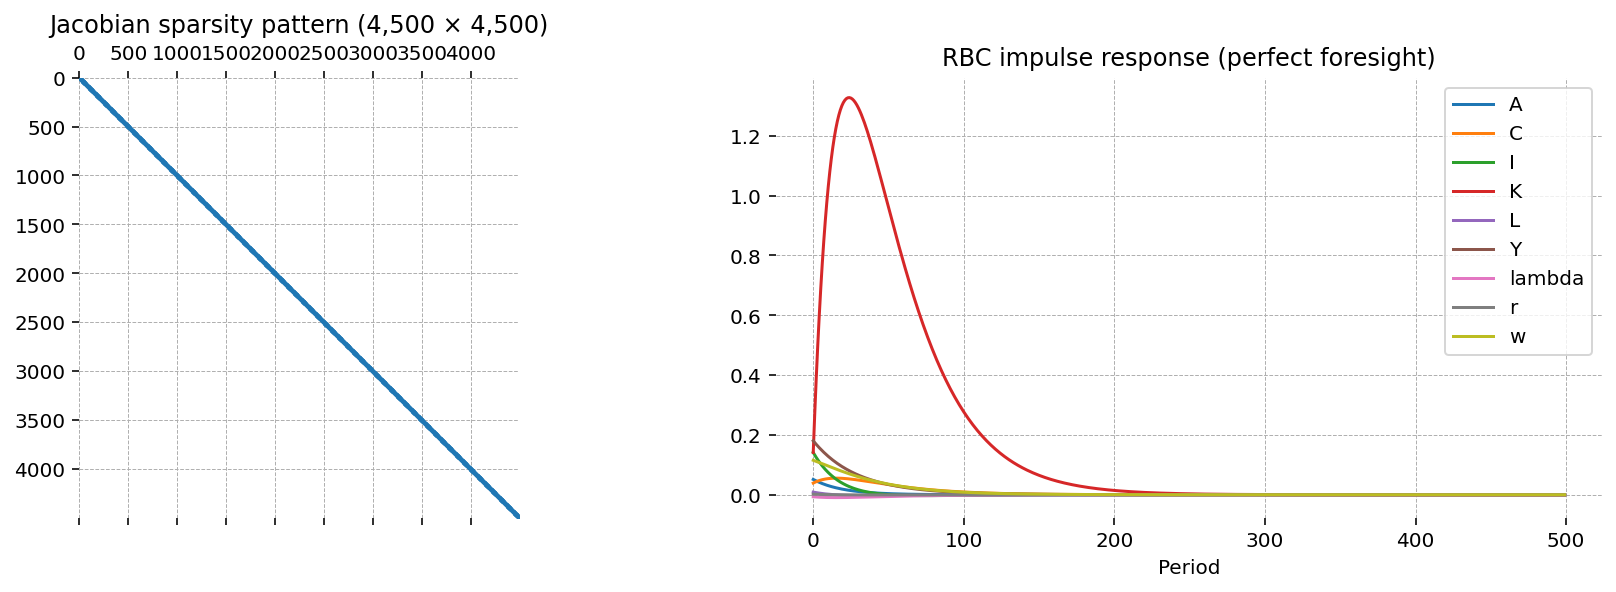

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].spy(result.jac, markersize=0.05)
axes[0].set_title(f"Jacobian sparsity pattern ({result.jac.shape[0]:,} × {result.jac.shape[1]:,})")

steady_state = pd.Series({k.removesuffix("_ss"): v for k, v in rbc.steady_state().items()})
(trajectory - steady_state).plot(ax=axes[1], legend=True)
axes[1].set_xlabel("Period")
axes[1].set_title("RBC impulse response (perfect foresight)")
plt.show()

The Jacobian has a banded structure — each period's equations only depend on variables at $t-1$, $t$,
and $t+1$. This is why sparse solvers are essential: a dense factorization of a matrix this size would
be extremely expensive.

### New Keynesian model with a custom solver

The New Keynesian model has more variables per period (sticky prices, sticky wages, monetary policy),
so the stacked system is considerably larger. Here we use `LevenbergMarquardt`, a trust-region solver
that adapts its damping parameter $\lambda$ each step.

In [16]:
nk = ge.model_from_gcn(ge.data.get_example_gcn("New_Keynesian"), verbose=False)

T_nk = 300
shock_nk = np.zeros(T_nk)
shock_nk[0] = 0.01

trajectory_nk, result_nk = ge.solve_perfect_foresight(
    nk, simulation_length=T_nk, shocks={"epsilon_R": shock_nk}, solver=LevenbergMarquardt()
)
print(f"Success: {result_nk.success}, iterations: {result_nk.nit}")

Output()

Success: True, iterations: 13


In [17]:
n_vars_nk = len(nk.variables)
print(f"{'Variables per period:':25} {n_vars_nk}")
print(f"{'Simulation length:':25} {T_nk}")
print(f"{'Total unknowns:':25} {T_nk * n_vars_nk:,}")
print(f"{'Jacobian shape':25} {result_nk.jac.shape}")
print(f"{'Jacobian nonzeros:':25} {result_nk.jac.nnz:,}")
print(f"{'Density:':25} {result_nk.jac.nnz / np.prod(result_nk.jac.shape):.6%}")

Variables per period:     23
Simulation length:        300
Total unknowns:           6,900
Jacobian shape            (6900, 6900)
Jacobian nonzeros:        31,764
Density:                  0.066717%


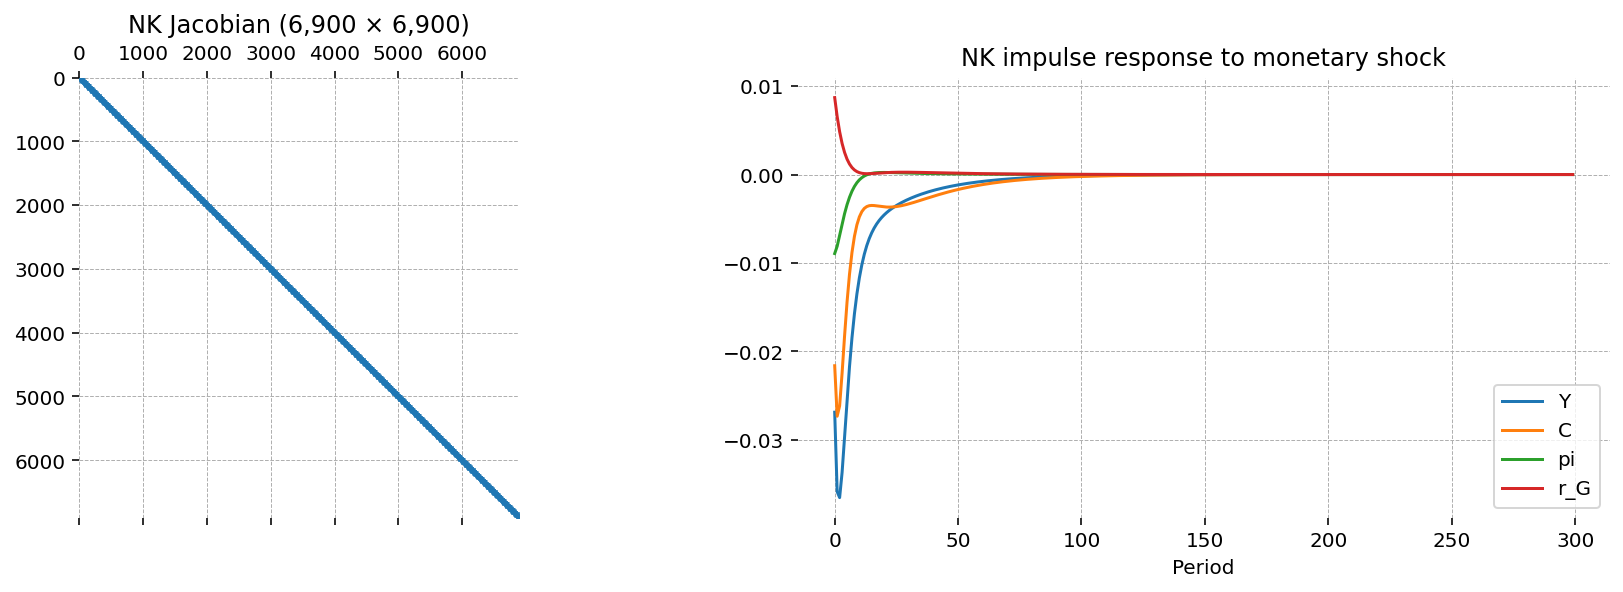

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].spy(result_nk.jac, markersize=0.02)
axes[0].set_title(f"NK Jacobian ({result_nk.jac.shape[0]:,} × {result_nk.jac.shape[1]:,})")

steady_state_nk = pd.Series({k.removesuffix("_ss"): v for k, v in nk.steady_state().items()})

(trajectory_nk - steady_state_nk)[["Y", "C", "pi", "r_G"]].plot(ax=axes[1])
axes[1].set_xlabel("Period")
axes[1].set_title("NK impulse response to monetary shock")
plt.show()

# Authors

- Authored by Jesse Grabowski in March 2026, with assistance from Claude Opus 4.6 

# Watermark

In [19]:
%load_ext watermark
%watermark -n -u -v -iv -w -p gEconpy

Last updated: Sun, 15 Mar 2026

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.11.0

gEconpy: 2.0.4.dev37+g9a1a488f7.d20260315

gEconpy   : 2.0.4.dev37+g9a1a488f7.d20260315
matplotlib: 3.10.8
numpy     : 2.4.2
pandas    : 3.0.1
scipy     : 1.17.1

Watermark: 2.6.0

